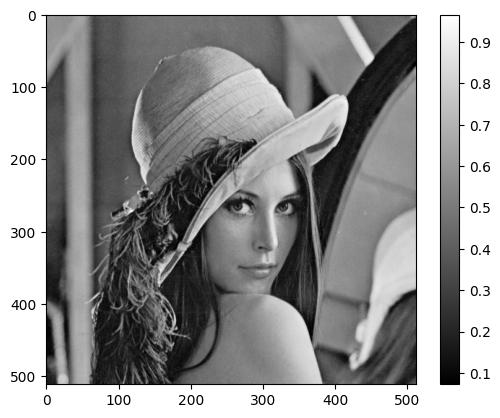

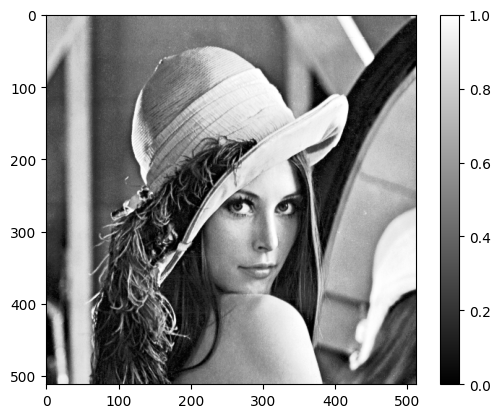

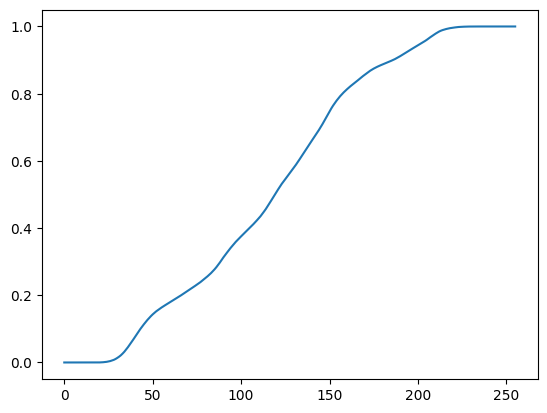

(<Figure size 640x480 with 1 Axes>,
 None)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import color, io


def egalizare_historagrama(img):
    h, _ = np.histogram(img, 256, (0, 1.000000001), density=True)
    # trebuie sa ii dau limitele de sus si de jos
    # limita de sus trebuie sa fie un pic mai mare decat 1

    # histograma cumulativa:
    H = np.cumsum(h)
    return h, H
# H = functia de transformare

img = io.imread('../lena.png')
Y = color.rgb2gray(img)  # intoarce floats in intervalul [0, 1]
plt.figure(), plt.imshow(Y, cmap='gray'), plt.colorbar(), plt.show()


# avem o problema pt ca histograma cumulativa pare sa depaseasca 250 => histograma cumulativa e ok, histograma nu e ce trebuie

# density = true nu ma ajuta, pt ca eu voiam sa fie normat la suma
# varianta corecta:
# 
# def egalizare_historagrama(img):
#     h, _ = np.histogram(img, 256, (0, 1.000000001), density=True)
#     h = h / np.sum(h)  # ca sa normam la 1
#     H = np.cumsum(h)
#     return h, H


def egalizare_historagrama(img):
    h, _ = np.histogram(img, 256, (0, 1.000000001))
    h = h / np.sum(h)  # ca sa normam la 1
    H = np.cumsum(h)

    [L, C] = np.shape(img)
    imgout = np.zeros((L, C))

    for l in range(L):
        for c in range(C):
            imgout[l, c] = H[np.uint8(255 * img[l, c])]
    return imgout, H


imgout, H = egalizare_historagrama(Y)
plt.figure(), plt.imshow(imgout, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()
plt.figure(), plt.plot(H), plt.show()

(348, 457, 4)


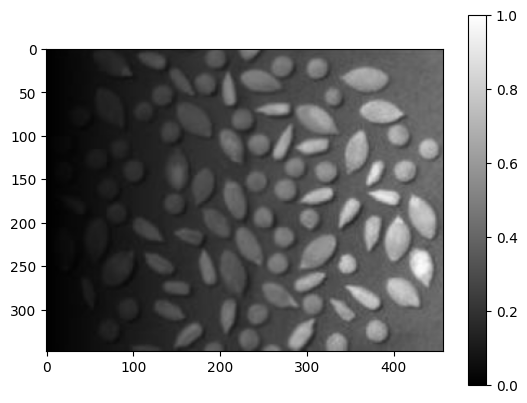

(<Figure size 640x480 with 2 Axes>,
 None)

In [14]:
img = io.imread('../uneven-grain.png')


print(np.shape(img)) # output: (348, 457, 4)
Y = img[:,:, 0] / 255.0 # impartim la 255 ca sa fie in intervalul 0, 1

plt.figure(), plt.imshow(img, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()


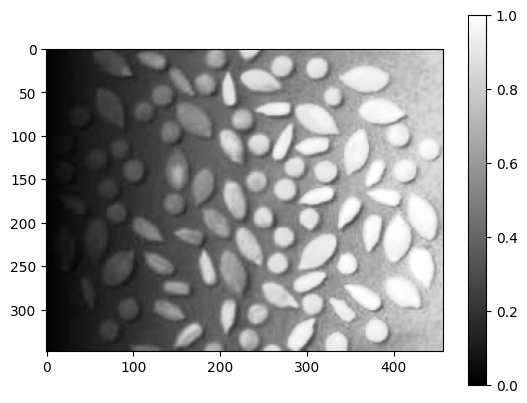

(<Figure size 640x480 with 2 Axes>,
 None)

In [15]:
# egalizare de histograma
Ynou, H = egalizare_historagrama(Y)

plt.figure(), plt.imshow(Ynou, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()


In [16]:
# de ce nu am obtinut rezultatul asteptat? (adica partea din stanga sa se lumineze)
# pt ca am calculat pe toata imaginea => trebuie sa folosim o tehnica adaptiva, prelucrarea mea trebuie sa fie localizata

# Adaptive Histogram Equalization (AHE)
def get_H_HE(img): # sa obtinem H de tranfer din Histogram Equalization(HE)
    h, _ = np.histogram(img, 256, (0, 1.000000001))
    h = h / np.sum(h)  # ca sa normam la 1
    H = np.cumsum(h)
    return H

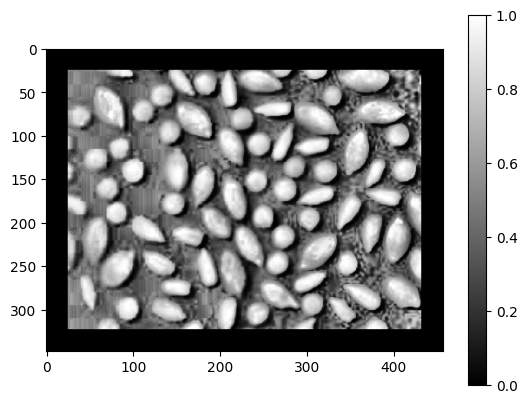

(<Figure size 640x480 with 2 Axes>,
 None)

In [22]:
[L, C] = np.shape(Y)
Yout = np.zeros((L, C))
W = 5 # de la punctul meu, merg W linii in sus, W linii in jos, la fel pt sus stanga si dreapta
# W = 5 e o fereastra cam mica la o imagine de 400
W = 25
for l in range(W, L - W):
    for c in range(W, C- W):
        ROI = Y[l-W: l+W+1, c-W:c+W+1]# region of interest - pun o fereastra patrata de dimensiune impara, W = dimensiunea lui ROI
        H = get_H_HE(ROI)
        Yout[l, c] = H[np.uint8(255 * Y[l, c])]
        
plt.figure(), plt.imshow(Yout, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()


(348, 457)
(398, 507)


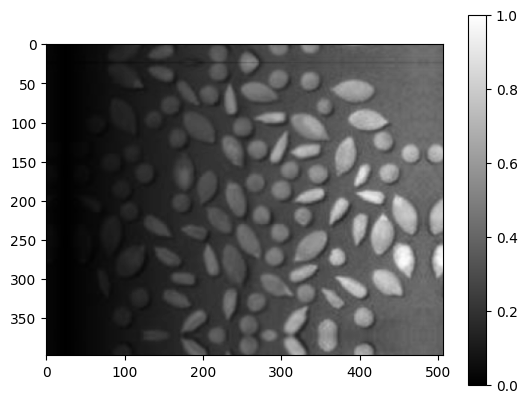

(<Figure size 640x480 with 2 Axes>,
 None)

In [24]:
# cum sa bordam imaginea
# !!! convolve2d de la scipy - mode

from scipy import signal

# convolve2d(in1, in2, mode='full', boundary='fill', fillvalue=0)
# in2 = nucleul

kernel = np.zeros((2*W+1, 2*W+1))
kernel[W, W] = 1
Ybordat = signal.convolve2d(Y, kernel, boundary='symm')

print(np.shape(Y))
print(np.shape(Ybordat))

plt.figure(), plt.imshow(Ybordat, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()


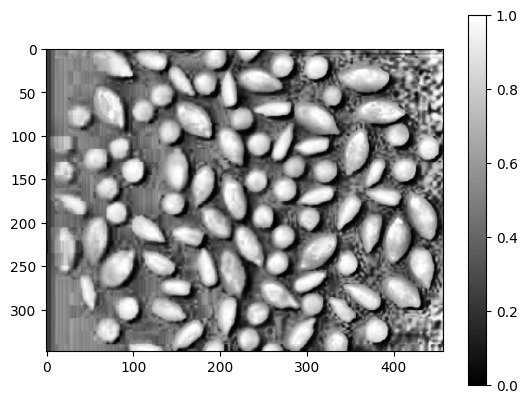

(<Figure size 640x480 with 2 Axes>,
 None)

In [25]:
Yout = np.zeros((L, C))
for l in range(0, L):
    for c in range(0, C):
        ROI = Ybordat[l-W+W: l+W+W+1, c-W+W:c+W+W+1]
        H = get_H_HE(ROI)
        Yout[l, c] = H[np.uint8(255 * Y[l, c])]
        
plt.figure(), plt.imshow(Yout, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(), plt.show()
# pe margini nu iese prea bine
        

(219, 259, 4)


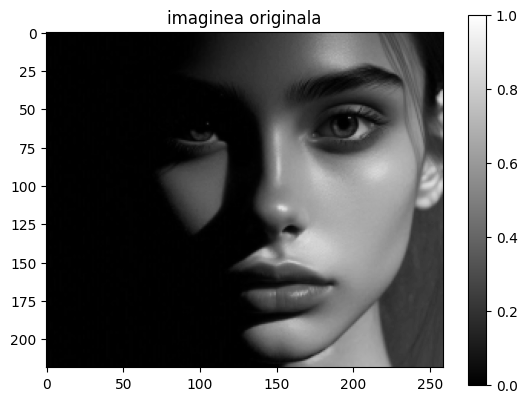

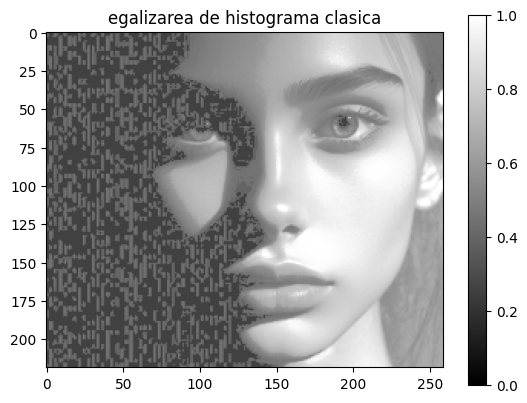

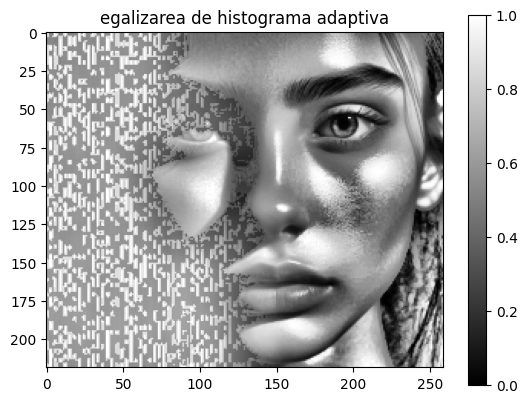

(<Figure size 640x480 with 2 Axes>,
 Text(0.5, 1.0, 'egalizarea de histograma adaptiva'),
 None)

In [33]:
img = io.imread('../uneven-face-mic.png')
print(np.shape(img))
Y = color.rgb2gray(img[:,:,0:3]) # excludem planul de transparenta

plt.figure(), plt.imshow(Y, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(),plt.title("imaginea originala"), plt.show()

# egalizarea de histograma clasica
Ynou, H = egalizare_historagrama(Y)
plt.figure(), plt.imshow(Ynou, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(),plt.title("egalizarea de histograma clasica"), plt.show()

# egalizarea de histograma adaptiva cu bordare
# bordare
W = 25
kernel = np.zeros((2*W+1, 2*W+1))
kernel[W, W] = 1
Ybordat = signal.convolve2d(Y, kernel, boundary='symm')

# egalizare de histograma adaptiva
[L, C] = np.shape(Y)
Yout = np.zeros((L, C))
for l in range(0, L):
    for c in range(0, C):
        ROI = Ybordat[l-W+W: l+W+W+1, c-W+W:c+W+W+1]
        H = get_H_HE(ROI)
        Yout[l, c] = H[np.uint8(255 * Y[l, c])]
        
plt.figure(), plt.imshow(Yout, cmap='gray', vmin = 0, vmax = 1), plt.colorbar(),plt.title("egalizarea de histograma adaptiva"), plt.show()


In [ ]:
def get_H_CLHE(img):
    h, _ = np.histogram(img, 256, (0, 1.000000001))
    h = h / np.sum(h)  # ca sa normam la 1
    
    # tema pentru acasa!!
    
    H = np.cumsum(h)
    return H